In [ ]:
"Importing The Libraries"
# Uses pandas and numpy for data handling and numerical operations.
# Uses matplotlib and seaborn for data visualization.
# Uses sklearn for data preprocessing and model building.
# Applies Random Forest Regression for house price prediction.
# Evaluates model performance using error metrics and displays dataset preview.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
data = pd.read_csv("house_price_raw_data.csv")
print("Dataset loaded ✅")
print(data.head())

Dataset loaded ✅
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [ ]:
 "Data Preprocessing and Data Type Conversion"
 # Converts Yes/No columns into categorical data.
# Treats furnishing status as a categorical feature.
# Converts important columns into proper numeric format.
# Handles invalid values by converting them to missing values.
# Improves data quality and model accuracy.

In [2]:
# Convert yes/no columns to categorical
yes_no_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']
for col in yes_no_cols:
    data[col] = data[col].astype('category')

# Furnishing status as categorical
data['furnishingstatus'] = data['furnishingstatus'].astype('category')

# Ensure numeric columns are numeric
numeric_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [ ]:
"Feature Selection and Identification of Data Types"
# Separates features and target variable.
# Identifies numerical and categorical columns.
# Helps apply correct preprocessing methods.
# Enables proper scaling and encoding.
# Improves model accuracy and stability.


In [3]:
# Separate features and target
X = data.drop('price', axis=1)
y = data['price']

# Automatically detect column types
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['category', 'object']).columns

print("Numerical features:", list(numerical_features))
print("Categorical features:", list(categorical_features))

Numerical features: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical features: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [ ]:
"Data Preprocessing Pipelines"
#Separates numerical and categorical features for proper preprocessing.
##Handles missing values to avoid errors during model training.
#Scales numerical data to improve model performance.
#Converts categorical data into numeric format using encoding.
#Combines all preprocessing steps into a single automated pipeline.

In [4]:
# Numeric pipeline: impute missing values + scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute missing values + one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine numeric and categorical pipelines
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [ ]:
"Model Building and Training"
# Creates a complete pipeline combining preprocessing and the Random Forest model.
# Uses Random Forest Regression for accurate house price prediction.
# Splits the dataset into training and testing sets.
# Trains the model using the training data.
# Confirms successful model training.

In [ ]:

# Full pipeline with Random Forest regressor
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model_pipeline.fit(X_train, y_train)
print("Model trained successfully ✅")

Model trained successfully ✅


In [ ]:

"Model Evaluation, Prediction, and Visualization"
# Evaluates the model using MAE, RMSE, and R² score.
# Predicts house prices for the test dataset.
# Takes user input to predict the price of a new house.
# Displays the predicted house price.
# Visualizes actual vs predicted prices using a scatter plot.

MAE : 1025961.1683486238
RMSE: 1403925.371676078
R²  : 0.610054593532394

Enter the details of your house:



💰 Predicted House Price: ₹5,074,681.50


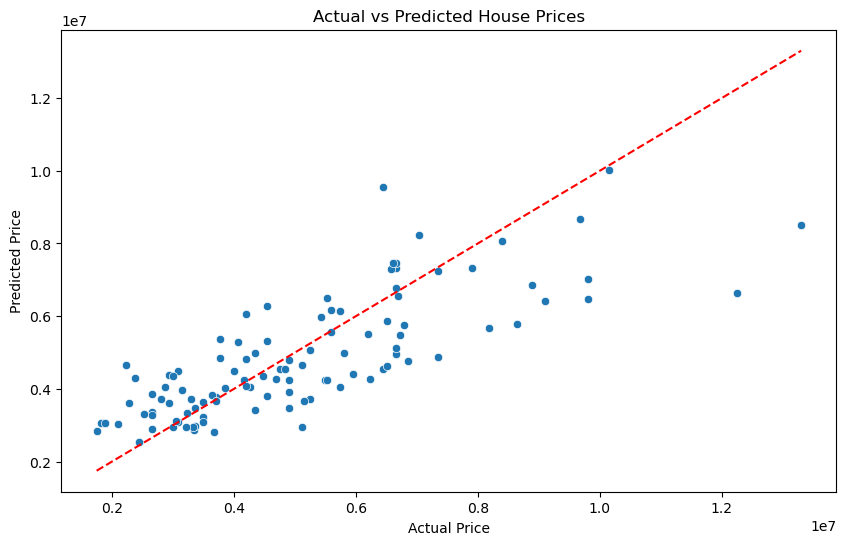

In [6]:
# Evaluate model
y_pred = model_pipeline.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

# Interactive input for new house prediction
print("\nEnter the details of your house:")

area = float(input("Enter area in sq ft: "))
bedrooms = int(input("Enter number of bedrooms: "))
bathrooms = int(input("Enter number of bathrooms: "))
stories = int(input("Enter number of stories: "))
mainroad = input("Main road access (yes/no): ")
guestroom = input("Guest room (yes/no): ")
basement = input("Basement (yes/no): ")
hotwaterheating = input("Hot water heating (yes/no): ")
airconditioning = input("Air conditioning (yes/no): ")
parking = int(input("Number of parking spots: "))
prefarea = input("Preferred area (yes/no): ")
furnishingstatus = input("Furnishing status (furnished/semi-furnished/unfurnished): ")

new_house = pd.DataFrame({
    'area': [area],
    'bedrooms': [bedrooms],
    'bathrooms': [bathrooms],
    'stories': [stories],
    'mainroad': [mainroad],
    'guestroom': [guestroom],
    'basement': [basement],
    'hotwaterheating': [hotwaterheating],
    'airconditioning': [airconditioning],
    'parking': [parking],
    'prefarea': [prefarea],
    'furnishingstatus': [furnishingstatus]
})

predicted_price = model_pipeline.predict(new_house)
print(f"\n💰 Predicted House Price: ₹{predicted_price[0]:,.2f}")

# Visualization: Actual vs Predicted Prices
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()